In [8]:
# =====================================================================
# SECTION 1: CLEAN ENVIRONMENT SETUP & DATA LOADING
# =====================================================================

# 1. Core Data Manipulation & Math Libraries
import numpy as np  # For fast matrix and numerical operations
import pandas as pd  # For handling structured DataFrames

# 2. Data Visualization Libraries
import matplotlib.pyplot as plt  # Core plotting engine
import missingno as msno  # To visualize missing data patterns
import plotly.express as px  # For interactive, dynamic charts
import seaborn as sns  # Advanced statistical plots

# 3. Machine Learning Models & Metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb
from sklearn.metrics import hamming_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("📦 Core data science and ML libraries loaded successfully!")

# =====================================================================
# DATA LOADING FROM LOCAL HARD DRIVE
# =====================================================================

# =====================================================================
# ONLY DATASET UPLOADING & LOADING PART
# =====================================================================
import os
import zipfile
import pandas as pd

# STEP 1: Define the path to your uploaded zip file.
# Since you used the "Copy path" option in Colab, paste it exactly here.
zip_path = "/archive.zip"

# STEP 2: Extract the contents of the zip file into Colab
print("🔄 Unzipping your file... please wait...")
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")
print("🔓 Unzipping complete!")

# STEP 3: Automatically find the newly extracted CSV file name
# This looks inside your folder and catches the CSV file automatically so you don't have to guess its name.
extracted_files = os.listdir("/content/")
csv_file = [file for file in extracted_files if file.endswith(".csv")][0]
print(f"📄 Found extracted CSV file: {csv_file}")

# STEP 4: Load the CSV file into a Pandas DataFrame called 'data'
print("⏳ Loading CSV data into memory...")
data = pd.read_csv(f"/content/{csv_file}")

print("\n🚀 SUCCESS! Your dataset is fully loaded and ready to use.")
print(f"Dataset Shape: {data.shape[0]} rows, {data.shape[1]} columns")

📦 Core data science and ML libraries loaded successfully!
🔄 Unzipping your file... please wait...
🔓 Unzipping complete!
📄 Found extracted CSV file: PS_20174392719_1491204439457_log.csv
⏳ Loading CSV data into memory...

🚀 SUCCESS! Your dataset is fully loaded and ready to use.
Dataset Shape: 6362620 rows, 11 columns


In [9]:
data


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [12]:
data.info()
print("-----------------SHAPE-----------------")
data.shape


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB
-----------------SHAPE-----------------


(6362620, 11)

<Axes: >

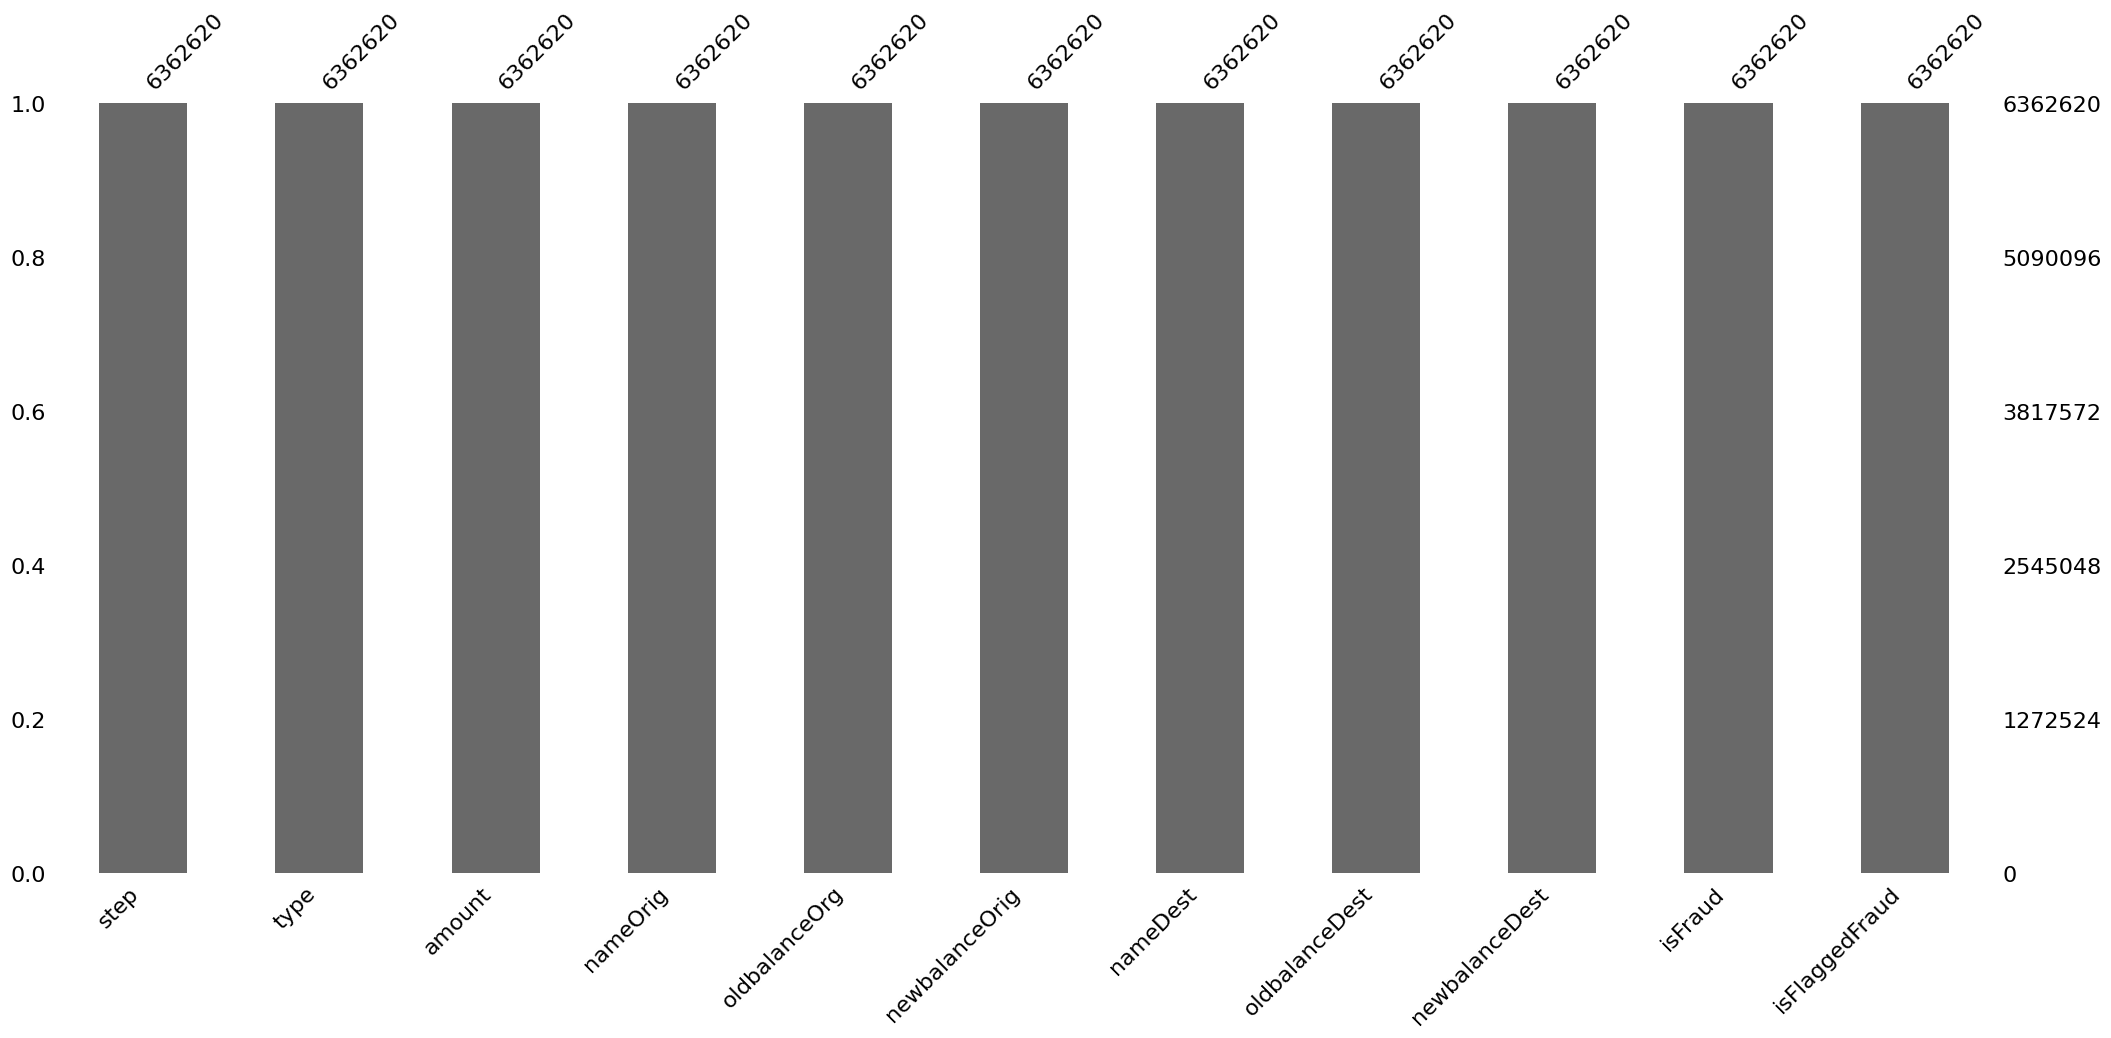

In [14]:
msno.bar(data)


In [15]:
duplicate_count = len(data[data.duplicated()])
duplicate_count

0

In [18]:
new_column_names = {
    'nameOrig': 'origin',
    'oldbalanceOrg': 'sender_old_bal',
    'newbalanceOrig': 'sender_new_bal',
    'nameDest': 'dest',
    'oldbalanceDest': 'dest_old_bal',
    'newbalanceDest': 'dest_new_bal'
}

data.rename(columns=new_column_names, inplace=True)

In [19]:
data

,step,type,amount,origin,sender_old_bal,sender_new_bal,dest,dest_old_bal,dest_new_bal,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [20]:
columns_to_drop = ['step', 'isFlaggedFraud']
data.drop(columns=columns_to_drop, inplace=True)

In [21]:
data

,type,amount,origin,sender_old_bal,sender_new_bal,dest,dest_old_bal,dest_new_bal,isFraud
0,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0
1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0
2,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1
3,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1
4,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0
...,...,...,...,...,...,...,...,...,...
6362615,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1
6362616,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1
6362617,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1
6362618,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1


In [22]:
def plot_fraud_by_transaction_type(data):
    plt.figure(figsize=(15, 8))
    g = sns.countplot(data=data, x='type', hue='isFraud', palette='dark', alpha=0.6)
    plt.title("Checking for fraud occurrences for each Transaction types")

    # Finding counts and annotating
    annotate_counts(g)

In [23]:
def annotate_counts(ax):
    for p in ax.patches:
        ax.annotate(p.get_height(), (p.get_x() + 0.04, p.get_height() + 10000))

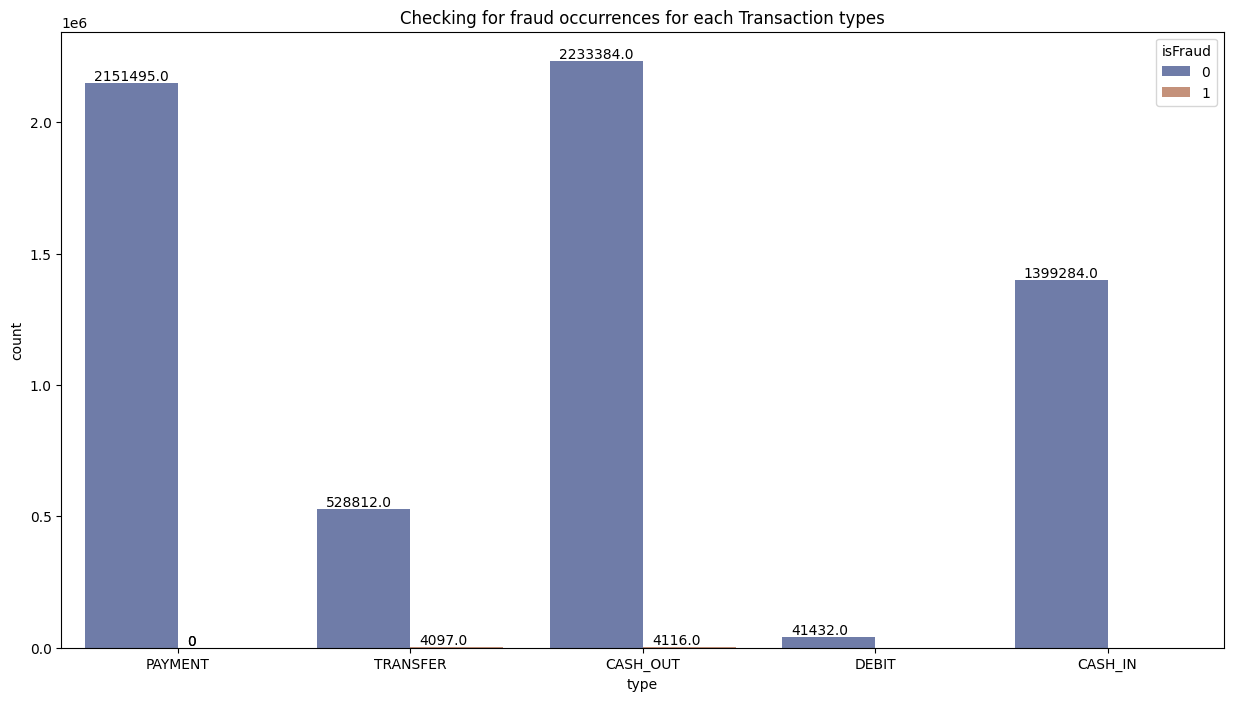

In [24]:
plot_fraud_by_transaction_type(data)
plt.show()


In [28]:
transfer_fraud = data[(data['type'] == 'TRANSFER') & (data['isFraud'] == 1)]
transfer_fraud_counts = data[(data['type'] == 'TRANSFER') & (data['isFraud'] == 1)]['origin'].value_counts()

In [26]:
transfer_fraud_counts

,count
origin,
C1685995037,1
C1565612524,1
C992223106,1
C1945606464,1
C88849251,1
...,...
C669700766,1
C1364127192,1
C1334405552,1


In [29]:
cashOut_fraud = data[(data['type']=='CASH_OUT') & (data['isFraud']==1)]
cashOut_fraud_count = data[(data['type']=='CASH_OUT') & (data['isFraud']==1)]['origin'].value_counts()

cashOut_fraud_count

,count
origin,
C1280323807,1
C840083671,1
C2101527076,1
C1118430673,1
C1597957921,1
...,...
C1499825229,1
C13692003,1
C1275464847,1


In [30]:
transfer_fraud['dest'].value_counts()

,count
dest,
C2080388513,1
C435734396,1
C1366804249,1
C625944676,1
C1939028448,1
...,...
C1384210339,1
C1136419747,1
C431687661,1


In [31]:
cashOut_fraud['dest'].value_counts()

,count
dest,
C1650668671,2
C644163395,2
C1013511446,2
C2129197098,2
C185805228,2
...,...
C1955464150,1
C1104137869,1
C377165949,1


In [32]:
is_dest_in_cashout_origin = transfer_fraud['dest'].isin(cashOut_fraud['origin']).any()
trans_cashout = data[data['type'] == 'TRANSFER']
is_dest_in_trans_cashout_origin = transfer_fraud['dest'].isin(trans_cashout['origin']).any()
count_dest_in_trans_cashout_origin = transfer_fraud['dest'].isin(trans_cashout['origin']).sum()
print(f"Is destination in cashOut origin? {is_dest_in_cashout_origin}")
print(f"Is destination in trans_cashout origin? {is_dest_in_trans_cashout_origin}")
print(f"Count of destinations in trans_cashout origin: {transfer_fraud.dest.isin(trans_cashout.origin).count()}")

Is destination in cashOut origin? False
Is destination in trans_cashout origin? True
Count of destinations in trans_cashout origin: 4097


Feature Engineering
Creating new column client_type having 4 categories and dropping 'origin' and 'dest'
CC - Customer to Customer
CM - Customer to Merchant
MC - Merchant to Customer
MM - Merchant to Merchant

In [39]:
print(data.columns)

Index(['type', 'amount', 'sender_old_bal', 'sender_new_bal', 'dest_old_bal',
       'dest_new_bal', 'isFraud'],
      dtype='object')


In [40]:
# 1. Filter the dataset to keep ONLY TRANSFER and CASH_OUT transactions
cleaned_df = data[data["type"].isin(["TRANSFER", "CASH_OUT"])].copy()

# 2. Calculate balance error for origin (sender) account
# In a perfect transaction: old_balance - amount = new_balance.
cleaned_df["errorBalanceOrig"] = (
    cleaned_df["sender_new_bal"]
    + cleaned_df["amount"]
    - cleaned_df["sender_old_bal"]
)

# 3. Calculate balance error for destination (receiver) account
# In a perfect transaction: old_balance + amount = new_balance.
cleaned_df["errorBalanceDest"] = (
    cleaned_df["dest_old_bal"] + cleaned_df["amount"] - cleaned_df["dest_new_bal"]
)

# 4. One-hot encode the 'type' column (converts TRANSFER/CASH_OUT into 1 and 0)
cleaned_df = pd.get_dummies(cleaned_df, columns=["type"], drop_first=True)

print("Cell 2 Success! Cleaned and engineered features successfully.")
print(f"Final dataset shape ready for ML: {cleaned_df.shape}")
cleaned_df.head(3)

Cell 2 Success! Cleaned and engineered features successfully.
Final dataset shape ready for ML: (2770409, 9)


,amount,sender_old_bal,sender_new_bal,dest_old_bal,dest_new_bal,isFraud,errorBalanceOrig,errorBalanceDest,type_TRANSFER
2,181.00,181.0,0.0,0.0,0.00,1,0.00,181.0,True
3,181.00,181.0,0.0,21182.0,0.00,1,0.00,21363.0,False
15,229133.94,15325.0,0.0,5083.0,51513.44,0,213808.94,182703.5,False


/tmp/ipykernel_11593/2364155334.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




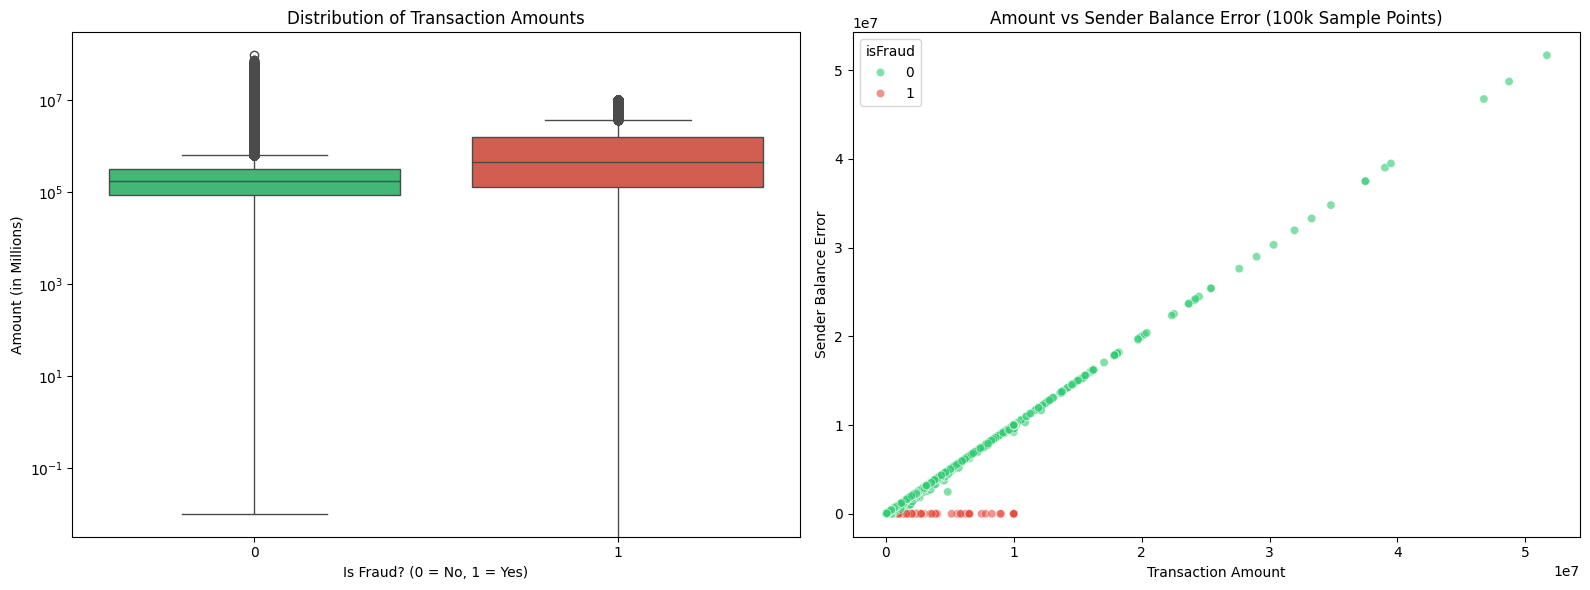

In [41]:
# =====================================================================
# DATA VISUALIZATION SECTION
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure canvas for two distinct plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Boxplot of Transaction Amounts (Fraud vs. Legitimate)
# This shows us if fraud cases involve significantly larger sums of money
sns.boxplot(
    ax=axes[0],
    x="isFraud",
    y="amount",
    data=cleaned_df,
    palette=["#2ecc71", "#e74c3c"],
)
axes[0].set_title("Distribution of Transaction Amounts")
axes[0].set_xlabel("Is Fraud? (0 = No, 1 = Yes)")
axes[0].set_ylabel("Amount (in Millions)")
axes[0].set_yscale("log")  # Using log scale to handle extreme outliers easily

# Plot 2: Scatter Plot of Error Balance vs. Transaction Amount
# This visualizes how our custom engineered feature instantly separates fraud from clean data
sns.scatterplot(
    ax=axes[1],
    x="amount",
    y="errorBalanceOrig",
    hue="isFraud",
    data=cleaned_df.sample(
        100000, random_state=42
    ),  # Sampling 100k points so Colab doesn't freeze
    palette=["#2ecc71", "#e74c3c"],
    alpha=0.6,
)
axes[1].set_title("Amount vs Sender Balance Error (100k Sample Points)")
axes[1].set_xlabel("Transaction Amount")
axes[1].set_ylabel("Sender Balance Error")

plt.tight_layout()
plt.show()

In [42]:
# =====================================================================
# SECTION 5: SPLITTING THE DATA
# =====================================================================

# 1. Separate our features (X) from our target label (y)
# 'isFraud' is what we want to predict, so it goes to y. Everything else goes to X.
X = cleaned_df.drop(columns=["isFraud"])
y = cleaned_df["isFraud"]

# 2. Split the data into 80% Training and 20% Testing
# We use 'stratify=y' because fraud is highly imbalanced. This ensures both the train
# and test sets get the exact same percentage of fraud cases.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Cell 5 Success! Data split completed safely.")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Fraud cases in Training Set: {sum(y_train)}")
print(f"Fraud cases in Testing Set: {sum(y_test)}")

Cell 5 Success! Data split completed safely.
Training Features Shape: (2216327, 8)
Testing Features Shape: (554082, 8)
Fraud cases in Training Set: 6570
Fraud cases in Testing Set: 1643


In [43]:
# =====================================================================
# SECTION 6: FEATURE SCALING
# =====================================================================

# 1. Initialize the StandardScaler
scaler = StandardScaler()

# 2. Fit and transform the training data
# 'Fit' calculates the mean and variance of X_train.
# 'Transform' applies the mathematical formula to scale the data.
X_train_scaled = scaler.fit_transform(X_train)

# 3. Transform the testing data
# CRITICAL: We ONLY transform X_test. We do NOT fit it.
X_test_scaled = scaler.transform(X_test)

print("Cell 6 Success! Feature scaling applied perfectly.")
print(f"Scaled Training sample (First row):\n{X_train_scaled[0]}")

Cell 6 Success! Feature scaling applied perfectly.
Scaled Training sample (First row):
[-0.27663443 -0.19201226 -0.10914006 -0.23001149 -0.26646462 -0.24451181
  0.04806802 -0.48791196]


In [44]:
# =====================================================================
# SECTION 7: LOGISTIC REGRESSION BASELINE
# =====================================================================

# 1. Initialize the model
# We use class_weight='balanced' to handle the heavy class imbalance automatically
log_reg = LogisticRegression(class_weight="balanced", random_state=42, max_iter=500)

# 2. Train the model on our scaled training data
print("⏳ Training Logistic Regression Baseline model... please wait...")
log_reg.fit(X_train_scaled, y_train)
print("🎯 Model training complete!")

# 3. Make predictions on the scaled testing data
y_pred = log_reg.predict(X_test_scaled)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[
    :, 1
]  # Probabilities needed for ROC-AUC

# 4. Evaluate using our specific fraud metrics
auc_score = roc_auc_score(y_test, y_pred_proba)
h_loss = hamming_loss(y_test, y_pred)

print("\n--- BASELINE EVALUATION METRICS ---")
print(f"ROC-AUC Score: {auc_score:.4f}")
print(f"Hamming Loss:  {h_loss:.6f}")

⏳ Training Logistic Regression Baseline model... please wait...
🎯 Model training complete!

--- BASELINE EVALUATION METRICS ---
ROC-AUC Score: 0.9761
Hamming Loss:  0.065099


In [45]:
# =====================================================================
# SECTION 7.1: DETAILED CONFUSION MATRIX & CLASSIFICATION REPORT
# =====================================================================
from sklearn.metrics import classification_report, confusion_matrix

# 1. Generate the Confusion Matrix
# This counts True Negatives, False Positives, False Negatives, and True Positives
cm = confusion_matrix(y_test, y_pred)

print("--- CONFUSION MATRIX BREAKDOWN ---")
print(f"True Legitimate Caught (True Negatives):   {cm[0][0]}")
print(f"False Alarms Raised (False Positives):     {cm[0][1]}")
print(f"Missed Fraud Cases (False Negatives):      {cm[1][0]}")
print(f"True Fraud Caught (True Positives):        {cm[1][1]}")

# 2. Print the Precision, Recall, and F1-Score
print("\n--- DETAILED CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred, target_names=["Legit", "Fraud"]))

--- CONFUSION MATRIX BREAKDOWN ---
True Legitimate Caught (True Negatives):   516567
False Alarms Raised (False Positives):     35872
Missed Fraud Cases (False Negatives):      198
True Fraud Caught (True Positives):        1445

--- DETAILED CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       Legit       1.00      0.94      0.97    552439
       Fraud       0.04      0.88      0.07      1643

    accuracy                           0.93    554082
   macro avg       0.52      0.91      0.52    554082
weighted avg       1.00      0.93      0.96    554082



In [46]:
# =====================================================================
# SECTION 8: RANDOM FOREST MODEL
# =====================================================================
from sklearn.ensemble import RandomForestClassifier

# 1. Initialize the Random Forest
# We use n_estimators=50 to train faster in Colab, and class_weight='balanced' for the imbalance.
rf_model = RandomForestClassifier(
    n_estimators=50, class_weight="balanced", random_state=42, n_jobs=-1
)

print("⏳ Training Random Forest (50 Trees)... This might take 1-2 minutes...")
rf_model.fit(X_train_scaled, y_train)
print("🎯 Random Forest training complete!")

# 2. Make predictions
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# 3. Print the new Confusion Matrix and Classification Report
print("\n--- RANDOM FOREST CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred_rf))

print("\n--- RANDOM FOREST CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_rf, target_names=["Legit", "Fraud"]))

⏳ Training Random Forest (50 Trees)... This might take 1-2 minutes...
🎯 Random Forest training complete!

--- RANDOM FOREST CONFUSION MATRIX ---
[[552439      0]
 [     6   1637]]

--- RANDOM FOREST CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    552439
       Fraud       1.00      1.00      1.00      1643

    accuracy                           1.00    554082
   macro avg       1.00      1.00      1.00    554082
weighted avg       1.00      1.00      1.00    554082



In [47]:
# =====================================================================
# SECTION 9: XGBOOST CLASSIFIER
# =====================================================================
from xgboost import XGBClassifier

# Calculate scale_pos_weight to help XGBoost handle the class imbalance
# Formula: total_negative_examples / total_positive_examples
neg_count = len(y_train) - sum(y_train)
pos_count = sum(y_train)
scale_weight = neg_count / pos_count

# 1. Initialize XGBoost with optimized production settings
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale_weight,
    random_state=42,
    tree_method="hist",  # Speeds up training significantly on large datasets
)

print("⏳ Training XGBoost Model... please wait...")
xgb_model.fit(X_train_scaled, y_train)
print("🎯 XGBoost training complete!")

# 2. Make predictions
y_pred_xgb = xgb_model.predict(X_test_scaled)

# 3. Print evaluation matrix
print("\n--- XGBOOST CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred_xgb))

print("\n--- XGBOOST CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_xgb, target_names=["Legit", "Fraud"]))

⏳ Training XGBoost Model... please wait...
🎯 XGBoost training complete!

--- XGBOOST CONFUSION MATRIX ---
[[551161   1278]
 [     8   1635]]

--- XGBOOST CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00    552439
       Fraud       0.56      1.00      0.72      1643

    accuracy                           1.00    554082
   macro avg       0.78      1.00      0.86    554082
weighted avg       1.00      1.00      1.00    554082



In [48]:
# =====================================================================
# SECTION 10: TENSORFLOW DEEP LEARNING NEURAL NETWORK
# =====================================================================
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

# 1. Calculate class weights for TensorFlow to balance the loss function
# Total samples / (2 * class_samples)
total_samples = len(y_train)
weight_for_0 = total_samples / (2.0 * (total_samples - sum(y_train)))
weight_for_1 = total_samples / (2.0 * sum(y_train))
class_weights = {0: weight_for_0, 1: weight_for_1}

# 2. Build the Multi-Layer Perceptron Architecture
nn_model = Sequential(
    [
        # Input Layer + First Hidden Layer (8 features in -> 32 neurons)
        Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),  # Randomly deactivates 20% of neurons to stop overfitting
        # Second Hidden Layer
        Dense(16, activation="relu"),
        Dropout(0.2),
        # Output Layer: Single neuron with Sigmoid outputs a probability between 0 and 1
        Dense(1, activation="sigmoid"),
    ]
)

# 3. Compile the model with Adam optimizer and Binary Crossentropy loss
nn_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Recall()],
)

print("⏳ Training the Neural Network (3 Epochs)... please wait...")
# 4. Train the network
history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=3,
    batch_size=2048,  # Large batch size helps process 2.2 million rows quickly
    class_weight=class_weights,
    validation_split=0.1,
    verbose=1,
)
print("🎯 Neural Network training complete!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



⏳ Training the Neural Network (3 Epochs)... please wait...
Epoch 1/3
974/974 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8991 - loss: 0.3106 - recall: 0.8670 - val_accuracy: 0.9476 - val_loss: 0.1587 - val_recall: 0.9139
Epoch 2/3
974/974 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - accuracy: 0.9331 - loss: 0.1899 - recall: 0.9211 - val_accuracy: 0.9463 - val_loss: 0.1468 - val_recall: 0.9607
Epoch 3/3
974/974 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.9453 - loss: 0.1567 - recall: 0.9404 - val_accuracy: 0.9630 - val_loss: 0.1127 - val_recall: 0.9637
🎯 Neural Network training complete!


In [49]:
# =====================================================================
# SECTION 10.1: NEURAL NETWORK EVALUATION
# =====================================================================

# 1. Generate probability predictions on the scaled test set
y_pred_proba_nn = nn_model.predict(X_test_scaled)

# 2. Convert probabilities to binary outcomes (0 or 1) using a 0.5 threshold
y_pred_nn = (y_pred_proba_nn >= 0.5).astype(int).flatten()

# 3. Print the Confusion Matrix and Classification Report
print("--- NEURAL NETWORK CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred_nn))

print("\n--- NEURAL NETWORK CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred_nn, target_names=["Legit", "Fraud"]))

17316/17316 ━━━━━━━━━━━━━━━━━━━━ 35s 2ms/step
--- NEURAL NETWORK CONFUSION MATRIX ---
[[531986  20453]
 [    67   1576]]

--- NEURAL NETWORK CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

       Legit       1.00      0.96      0.98    552439
       Fraud       0.07      0.96      0.13      1643

    accuracy                           0.96    554082
   macro avg       0.54      0.96      0.56    554082
weighted avg       1.00      0.96      0.98    554082



In [52]:
# =====================================================================
# SECTION 11: FINAL MODEL COMPARISON METRICS (FIXED IMPORTS)
# =====================================================================
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

# 1. Gather metrics for all trained models
model_metrics = {
    "Model Name": [
        "Logistic Regression (Baseline)",
        "Random Forest",
        "XGBoost Classifier",
        "Neural Network (Keras)",
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_nn),
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_xgb),
        precision_score(y_test, y_pred_nn),
    ],
    "Recall (Sensitivity)": [
        recall_score(y_test, y_pred),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_xgb),
        recall_score(y_test, y_pred_nn),
    ],
    "F1-Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_nn),
    ],
}

# 2. Convert to a DataFrame and display beautifully
comparison_df = pd.DataFrame(model_metrics)
print("--- END-TO-END MODEL PERFORMANCE EVALUATION ---")
comparison_df.round(4)

--- END-TO-END MODEL PERFORMANCE EVALUATION ---


,Model Name,Accuracy,Precision,Recall (Sensitivity),F1-Score
0,Logistic Regression (Baseline),0.9349,0.0387,0.8795,0.0742
1,Random Forest,1.0000,1.0000,0.9963,0.9982
2,XGBoost Classifier,0.9977,0.5613,0.9951,0.7177
3,Neural Network (Keras),0.9630,0.0715,0.9592,0.1332


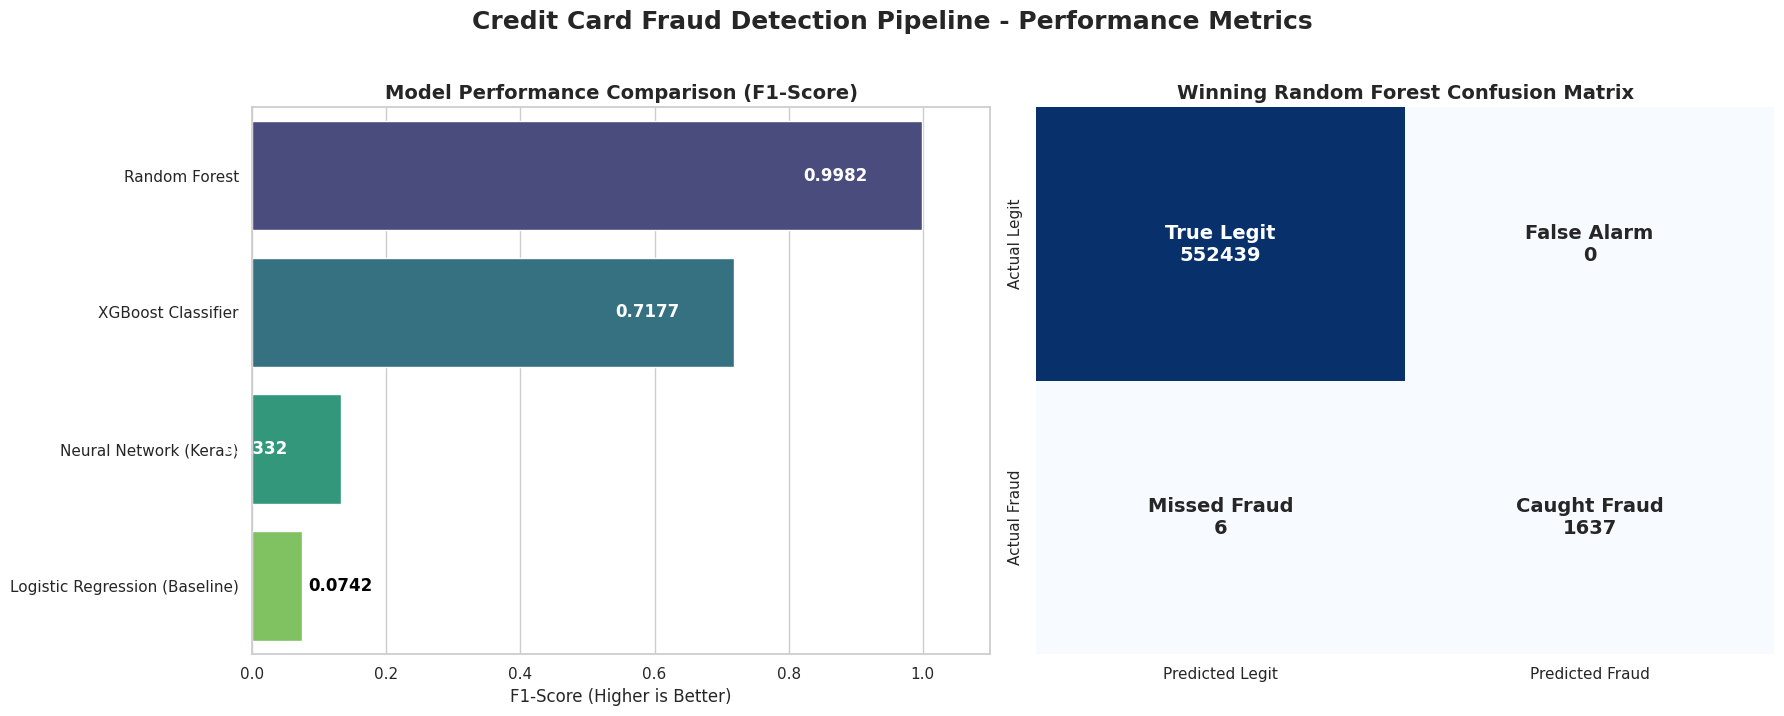

In [53]:
# =====================================================================
# GRAPHICAL VISUALIZATION DASHBOARD
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional aesthetic
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ---------------------------------------------------------------------
# PLOT 1: F1-Score Model Comparison Bar Chart
# ---------------------------------------------------------------------
# Sorting data for better visual flow
sorted_df = comparison_df.sort_values(by="F1-Score", ascending=False)

barplot = sns.barplot(
    ax=axes[0],
    x="F1-Score",
    y="Model Name",
    data=sorted_df,
    palette="viridis",
    hue="Model Name",
    legend=False,
)

# Add value labels to the end of each bar
for index, value in enumerate(sorted_df["F1-Score"]):
    axes[0].text(
        value - 0.08 if value > 0.1 else value + 0.01,
        index,
        f"{value:.4f}",
        va="center",
        ha="right" if value > 0.1 else "left",
        color="white" if value > 0.1 else "black",
        fontweight="bold",
    )

axes[0].set_title(
    "Model Performance Comparison (F1-Score)", fontsize=14, fontweight="bold"
)
axes[0].set_xlabel("F1-Score (Higher is Better)", fontsize=12)
axes[0].set_ylabel("")
axes[0].set_xlim(0, 1.1)

# ---------------------------------------------------------------------
# PLOT 2: Random Forest Confusion Matrix Heatmap
# ---------------------------------------------------------------------
# Re-generating the winning model's matrix array
rf_cm = confusion_matrix(y_test, y_pred_rf)

# Dynamic labels with text description for clarity
labels = [
    [f"True Legit\n{rf_cm[0][0]}", f"False Alarm\n{rf_cm[0][1]}"],
    [f"Missed Fraud\n{rf_cm[1][0]}", f"Caught Fraud\n{rf_cm[1][1]}"],
]

sns.heatmap(
    rf_cm,
    ax=axes[1],
    annot=labels,
    fmt="",
    cmap="Blues",
    cbar=False,
    annot_kws={"size": 14, "fontweight": "bold"},
    xticklabels=["Predicted Legit", "Predicted Fraud"],
    yticklabels=["Actual Legit", "Actual Fraud"],
)

axes[1].set_title(
    "Winning Random Forest Confusion Matrix", fontsize=14, fontweight="bold"
)
axes[1].tick_params(axis="both", which="major", labelsize=11)

# Final clean adjustments
plt.suptitle(
    "Credit Card Fraud Detection Pipeline - Performance Metrics",
    fontsize=18,
    fontweight="bold",
    y=1.02,
)
plt.tight_layout()
plt.show()

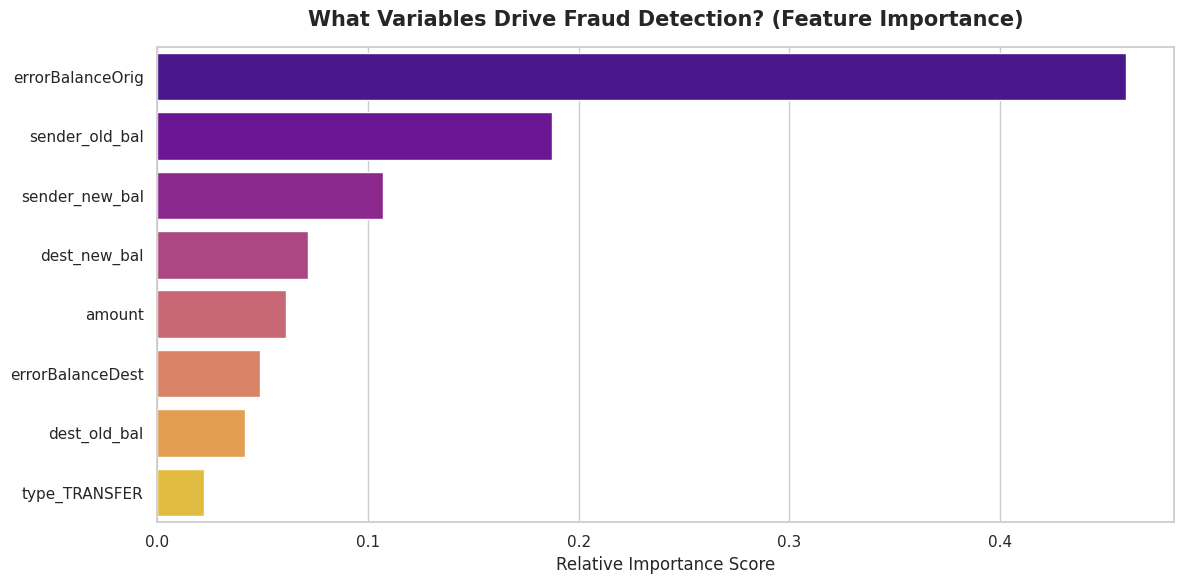

In [54]:
# =====================================================================
# FEATURE IMPORTANCE VISUALIZATION
# =====================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract feature importances from the trained Random Forest
importances = rf_model.feature_importances_
feature_names = X_train.columns

# 2. Create a DataFrame sorted by importance
feat_imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance Score": importances
}).sort_values(by="Importance Score", ascending=False)

# 3. Plot the data
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create a horizontal bar plot for maximum scannability
sns.barplot(
    x="Importance Score",
    y="Feature",
    data=feat_imp_df,
    palette="plasma",
    hue="Feature",
    legend=False
)

# Customize fonts and layout to match the dashboard aesthetic
plt.title("What Variables Drive Fraud Detection? (Feature Importance)", fontsize=15, fontweight="bold", pad=15)
plt.xlabel("Relative Importance Score", fontsize=12)
plt.ylabel("")
plt.tight_layout()
plt.show()

In [58]:
# =====================================================================
# SECTION 12: SAVING THE MODEL & SCALER FOR PRODUCTION
# =====================================================================
import pickle

# 1. Save the trained Random Forest model to a file
model_filename = "winning_random_forest_model.pkl"
with open(model_filename, "wb") as model_file:
    pickle.dump(rf_model, model_file)

# 2. Save the StandardScaler (CRITICAL: You must use the exact same scaler for new data!)
scaler_filename = "production_scaler.pkl"
with open(scaler_filename, "wb") as scaler_file:
    pickle.dump(scaler, scaler_file)

print("--- PIPELINE ARTIFACTS SAVED SUCCESSFULLY ---")
print(f"1. Saved Model File:  {model_filename}")
print(f"2. Saved Scaler File: {scaler_filename}")
print(
    "\n💡 Success: Refresh your Google Colab left sidebar file explorer. You will see both files there ready to download!"
)

--- PIPELINE ARTIFACTS SAVED SUCCESSFULLY ---
1. Saved Model File:  winning_random_forest_model.pkl
2. Saved Scaler File: production_scaler.pkl

💡 Success: Refresh your Google Colab left sidebar file explorer. You will see both files there ready to download!


In [60]:
from google.colab import files

# Force download the model
print("Downloading model...")
files.download("winning_random_forest_model.pkl")

# Force download the scaler
print("Downloading scaler...")
files.download("production_scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>